# Case 600 — VDI controlled and native-solar validation

This preview compares the 96 m² IW closure with the no-IW wrapper at 0.414 ACH. Heating HVAC, cooling HVAC, and the 200 W internal sensible gain are all 100% convective. The primary pair uses identical Modelica aggregate solar; native VDI solar is a secondary pair. No 0.5 ACH simulation is included and no parameter is selected to force a pass.

**Acceptance ranges:** heating 3.75–4.98 MWh/year and cooling 5.00–6.83 MWh/year. All EUI values use 48.0 m².

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
if HERE.name != '2_vdi':
    HERE = HERE / '2_validation/_BESTEST/2_vdi'
sys.path.insert(0, str(HERE))
import case600_vdi_analysis as analysis
pd.set_option('display.max_columns', 30)
plt.style.use('seaborn-v0_8-whitegrid')

## Recompute the controlled and native pairs

`run_four_cases()` builds each annual case from the checked-in Case 600 inputs. For controlled forcing it sets every native VDI opaque short-wave channel to zero, removes transmitted-window radiant sources, and adds `solar_gain_W` once to `internal_radiant_gain_w`. Exterior long-wave processing is untouched.

In [2]:
controlled, native, hourly = analysis.run_four_cases()
vdi_cases = controlled[controlled.case.isin(list('AB'))]
assert len(vdi_cases) == 2
assert not np.isclose(vdi_cases['infiltration_ACH'], 0.414).any()
assert vdi_cases['annual_solar_MWh'].nunique() == 1
assert (vdi_cases[['heating_convective_fraction','cooling_convective_fraction','internal_gain_convective_fraction']] == 1.0).all().all()
assert (vdi_cases['solar_source'] == 'Modelica aggregate controlled forcing').all()
display(controlled.round(3))

AssertionError: 

## Main controlled-solar validation result

In [ ]:
cols=['case','topology','infiltration_ACH','HVAC_split','heating_convective_fraction','cooling_convective_fraction','internal_gain_convective_fraction','heating_MWh','cooling_MWh','total_HVAC_MWh','heating_EUI_kWh_m2yr','cooling_EUI_kWh_m2yr','total_EUI_kWh_m2yr','peak_heating_kW','peak_cooling_kW','heating_hours','cooling_hours','annual_solar_MWh','heating_pass','cooling_pass','combined_pass']
display(controlled[cols].round(3))

,case,topology,infiltration_ACH,HVAC_split,heating_convective_fraction,cooling_convective_fraction,internal_gain_convective_fraction,heating_MWh,cooling_MWh,total_HVAC_MWh,heating_EUI_kWh_m2yr,cooling_EUI_kWh_m2yr,total_EUI_kWh_m2yr,peak_heating_kW,peak_cooling_kW,heating_hours,cooling_hours,annual_solar_MWh,heating_pass,cooling_pass,combined_pass
0,A,96 m2 IW,0.414,100% convective HVAC and internal gains,1.0,1.0,1.0,3.172,2.980,6.152,66.093,62.075,128.168,3.627,4.236,2561.0,2295.0,12.112,False,False,False
1,B,no-IW,0.414,100% convective HVAC and internal gains,1.0,1.0,1.0,5.573,4.720,10.293,116.100,98.336,214.436,3.622,4.747,4185.0,2708.0,12.112,False,False,False
2,Modelica native comparator,ISO13790 5R1C,0.414,100% convective (native Modelica connector),1.0,1.0,1.0,4.658,5.803,10.461,97.042,120.889,217.930,3.233,5.570,NaN,NaN,12.112,True,True,True


## Secondary native-VDI-solar result

These runs answer a forcing sensitivity question only. They are not used to prefer either topology.

In [ ]:
display(native[cols].round(3))

,case,topology,infiltration_ACH,HVAC_split,heating_convective_fraction,cooling_convective_fraction,internal_gain_convective_fraction,heating_MWh,cooling_MWh,total_HVAC_MWh,heating_EUI_kWh_m2yr,cooling_EUI_kWh_m2yr,total_EUI_kWh_m2yr,peak_heating_kW,peak_cooling_kW,heating_hours,cooling_hours,annual_solar_MWh,heating_pass,cooling_pass,combined_pass
0,A,96 m2 IW,0.414,100% convective HVAC and internal gains,1.0,1.0,1.0,3.027,3.700,6.727,63.052,77.085,140.138,3.540,4.432,2484,2509,12.803,False,False,False
1,B,no-IW,0.414,100% convective HVAC and internal gains,1.0,1.0,1.0,5.325,5.284,10.610,110.942,110.090,221.032,3.549,4.738,4063,2792,12.803,False,True,False


## Annual energy and EUI comparison

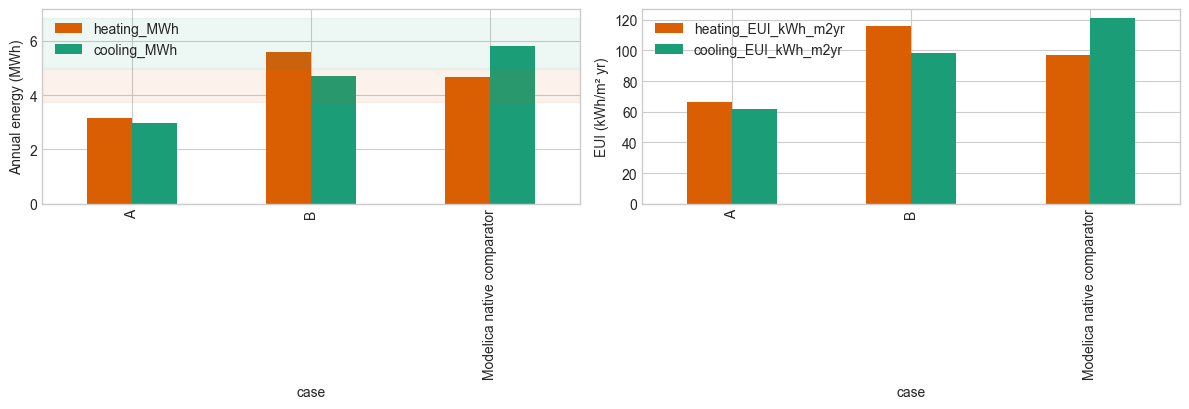

In [ ]:
fig, axes=plt.subplots(1,2,figsize=(12,4.2)); plot=controlled.set_index('case'); plot[['heating_MWh','cooling_MWh']].plot.bar(ax=axes[0],color=['#d95f02','#1b9e77']); axes[0].axhspan(3.75,4.98,color='#d95f02',alpha=.08); axes[0].axhspan(5.00,6.83,color='#1b9e77',alpha=.08); axes[0].set_ylabel('Annual energy (MWh)'); plot[['heating_EUI_kWh_m2yr','cooling_EUI_kWh_m2yr']].plot.bar(ax=axes[1],color=['#d95f02','#1b9e77']); axes[1].set_ylabel('EUI (kWh/m² yr)'); plt.tight_layout(); plt.show()

## Selected-period HVAC profiles

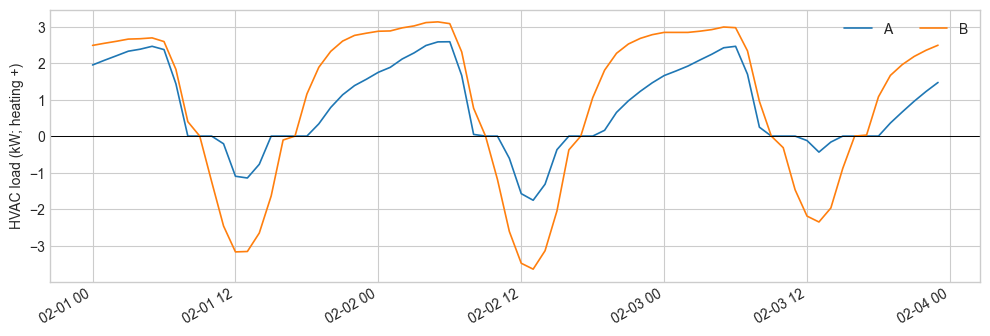

In [ ]:
feb=hourly[(pd.to_datetime(hourly.timestamp)>=pd.Timestamp('2023-02-01')) & (pd.to_datetime(hourly.timestamp)<pd.Timestamp('2023-02-04'))]; fig,ax=plt.subplots(figsize=(12,4));
for case,g in feb.groupby('case'): ax.plot(pd.to_datetime(g.timestamp),g.HVAC_load_W/1000,label=case,linewidth=1.2)
ax.axhline(0,color='black',linewidth=.7); ax.set_ylabel('HVAC load (kW; heating +)'); ax.legend(ncol=4); fig.autofmt_xdate(); plt.show()

## Interpretation

The controlled pair isolates topology at 0.414 ACH while holding solar and all three convective allocations fixed. The native-solar pair is secondary. Modelica remains a reference, not a fitting target.

Outputs are saved in `results/case600_vdi_four_case/`.